In [2]:
import numpy as np
from pathlib import Path

from model_ranking.datasets import get_datasets
from model_ranking.dataclass import EPFLTargetConfig

INFO: P [MainThread] 2025-06-11 16:16:15,256 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [3]:
import re
def alphanum_key(s: str):
    # Split string into list of strings and integers for natural sorting
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', str(s))]

In [4]:
from numpy.typing import NDArray
from typing import Any, List
import matplotlib.pyplot as plt
def consis_score_histogram(
    scores: NDArray[Any], 
    consistency_threshold:float,
    percentiles: List[float] = [60, 75, 90], 
    colors: List[str] = ['r', 'g', 'c'],
    title_postfix: str = '',
    ) -> None:
    assert len(percentiles) == len(colors), (
        "percentiles and colors must both be None or both be lists of the same length"
    )
    _ = plt.figure(figsize=(10, 5))
    _ = plt.subplot(1, 2, 1)
    _ = plt.hist(scores, bins=50, weights=np.ones(len(scores)) / len(scores), alpha=0.7)
    for p, c in zip(percentiles, colors):
        perc = np.nanpercentile(scores, p)
        _ = plt.axvline(perc, linestyle='--', color=c, label=f'{p}th percentile ({perc:.2f})')

    # Plot the consistency threshold line
    _ = plt.axvline(
        consistency_threshold, 
        linestyle='--', 
        color='k', 
        label=f'% scores above CT ({np.sum(scores > consistency_threshold) / np.sum(~np.isnan(scores)):.3f})')

    plt.grid()
    _ = plt.title(f"patchwise consistency scores: {title_postfix}")
    _ = plt.xlabel('Consistency Scores')
    _ = plt.ylabel('frequency')
    _ = plt.legend()
    plt.show()

In [14]:
list(range(0, 2 * len(scores_above_threshold), 2))

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

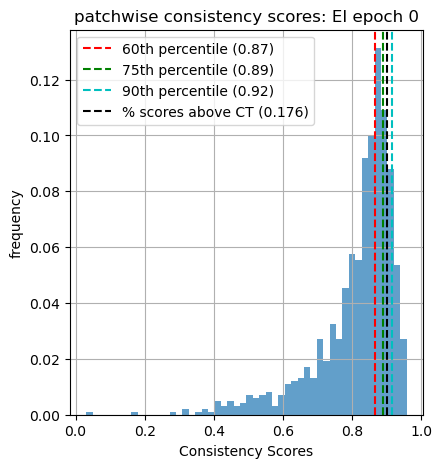

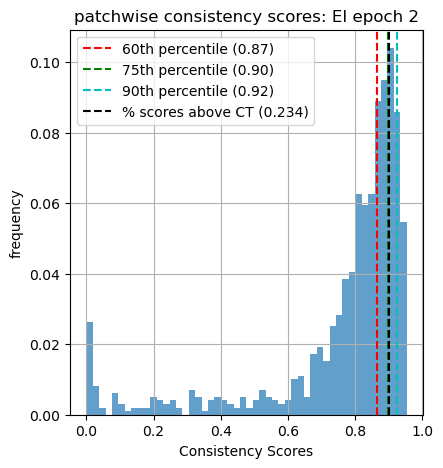

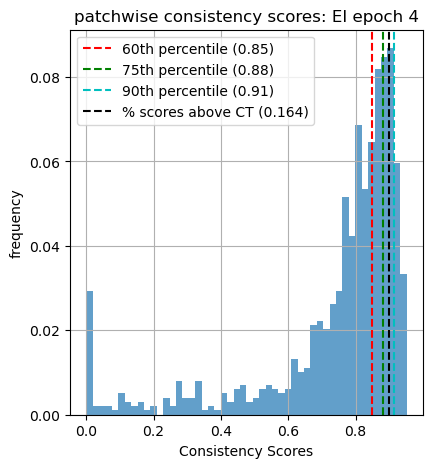

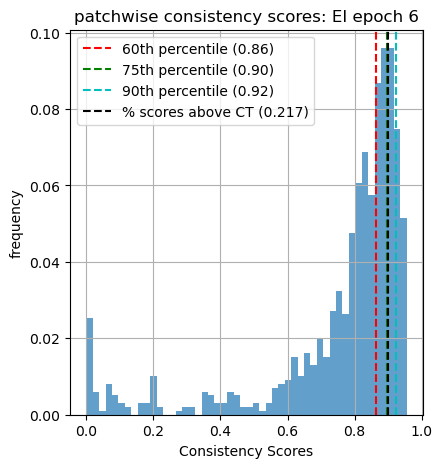

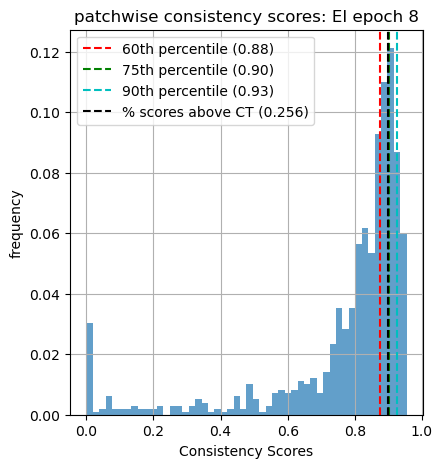

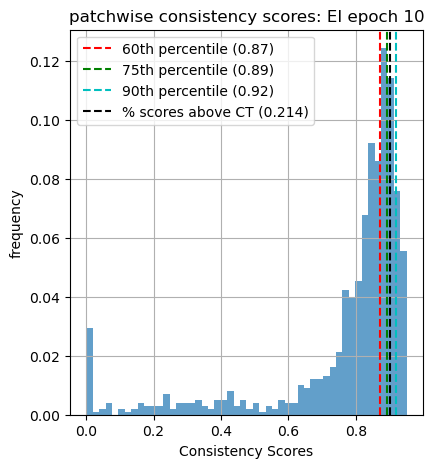

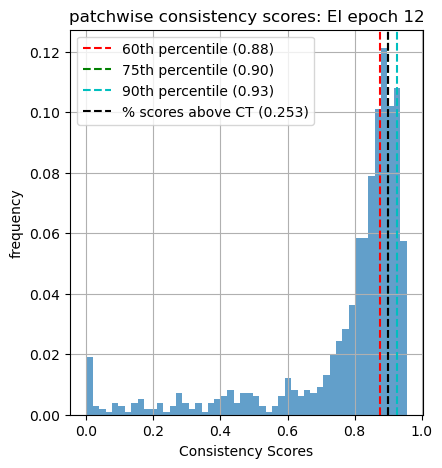

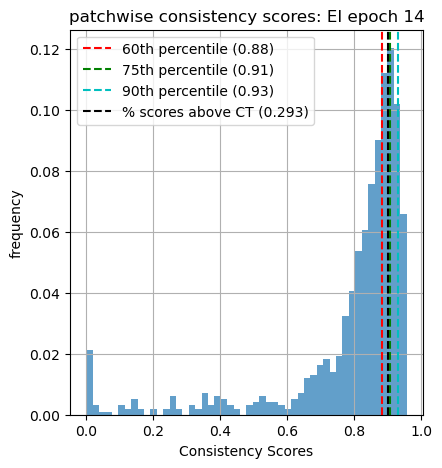

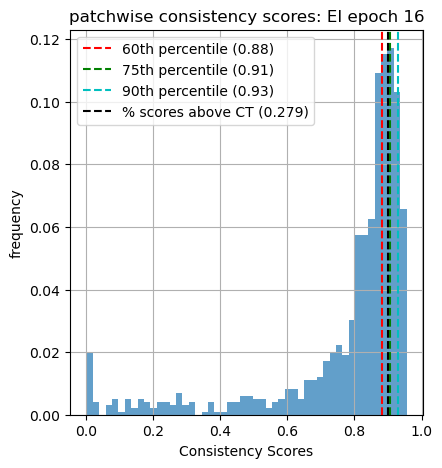

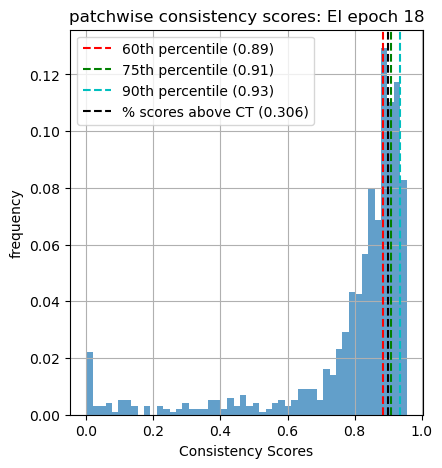

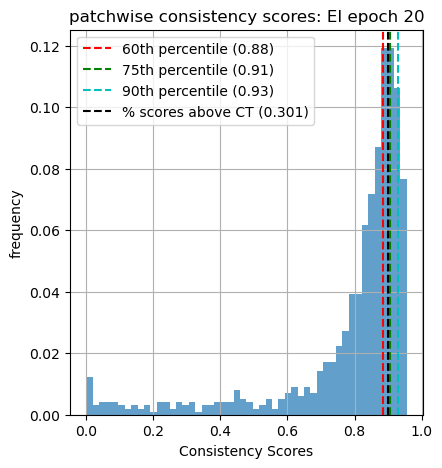

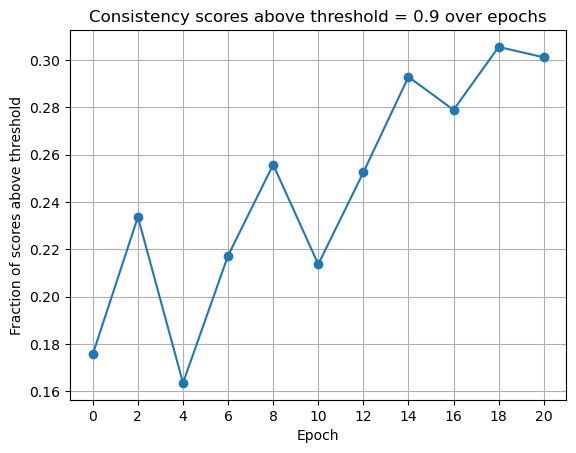

In [15]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_EI"
paths = Path(base_dir_path).glob("*.npz")
data_paths: List[Path] = list(sorted(paths, key=alphanum_key))
consistency_threshold = 0.9
scores_above_threshold: List[float] = []
for i, data_path in enumerate(data_paths):
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = np.load(data_path, allow_pickle=True)['consis_scores']
    scores_above_threshold.append(np.sum(consis_scores > consistency_threshold) / np.sum(~np.isnan(consis_scores)))
    consis_score_histogram(
        consis_scores, 
        consistency_threshold,
        title_postfix=f"EI epoch {2*i}"
    )
_ = plt.plot(list(range(0, 2 * len(scores_above_threshold), 2)), scores_above_threshold, marker='o')
_ = plt.grid()
_ = plt.xticks(list(range(0, 2 * len(scores_above_threshold), 2)))
_ = plt.title(f"Consistency scores above threshold = {consistency_threshold} over epochs")
_ = plt.xlabel("Epoch")
_ = plt.ylabel("Fraction of scores above threshold")
plt.show()

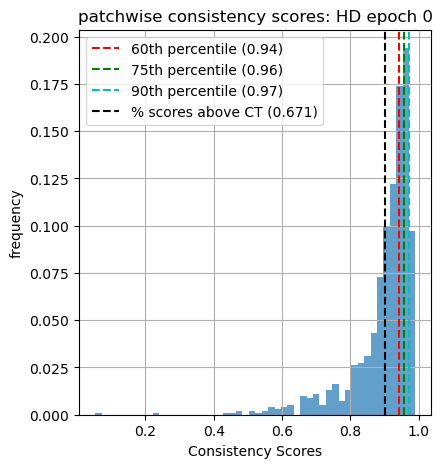

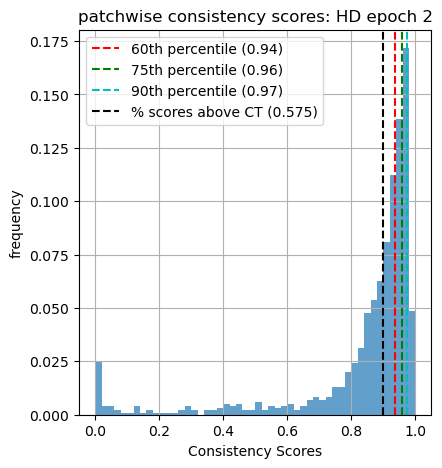

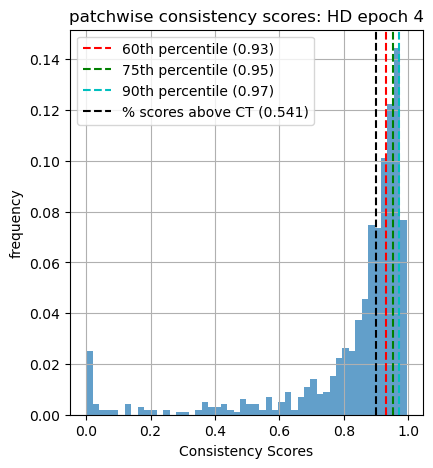

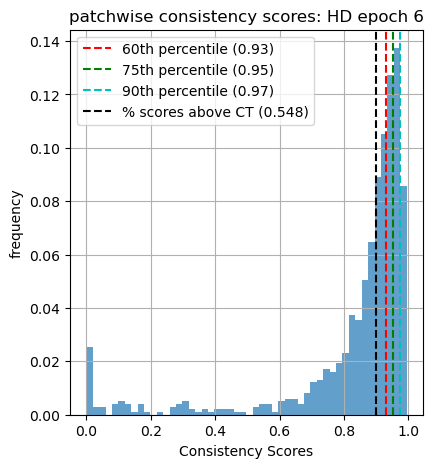

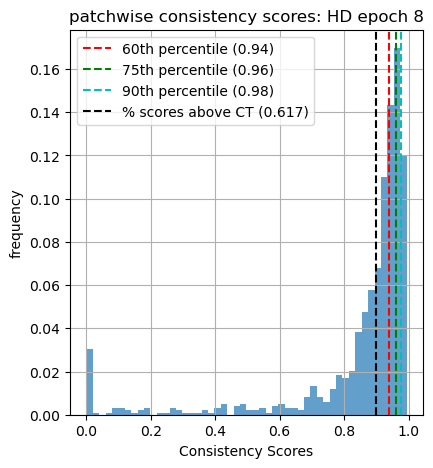

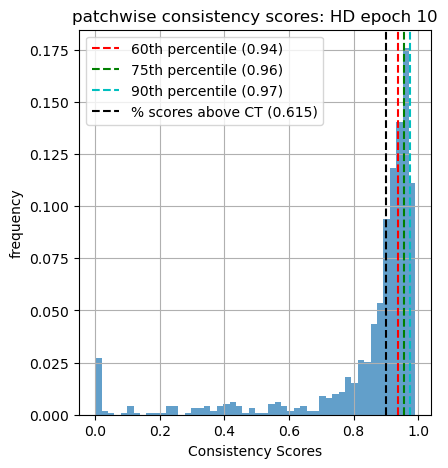

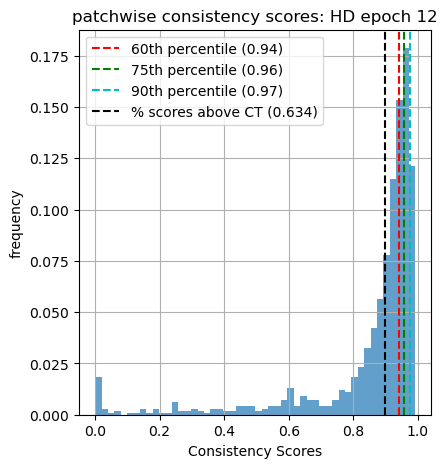

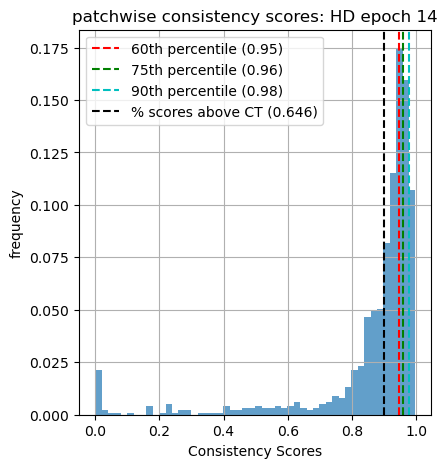

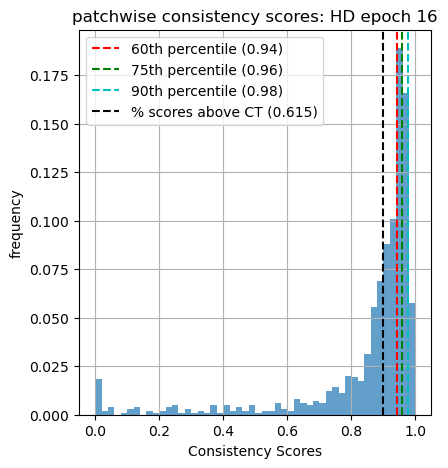

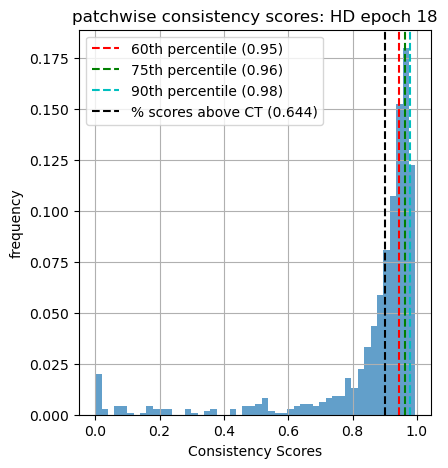

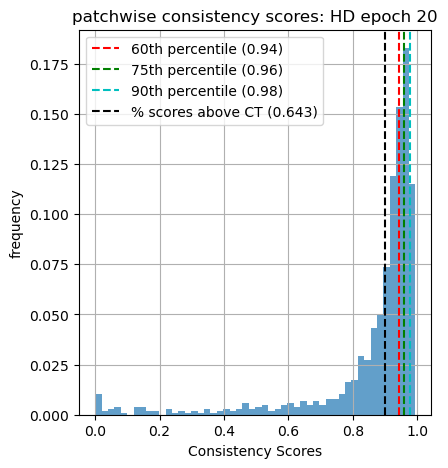

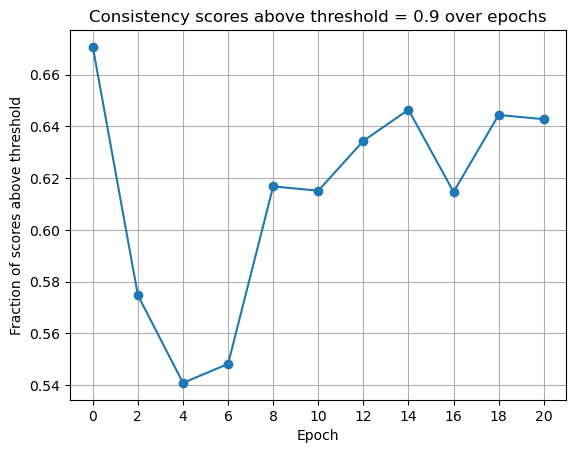

In [17]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_HD"
paths = Path(base_dir_path).glob("*.npz")
data_paths: List[Path] = list(sorted(paths, key=alphanum_key))
consistency_threshold = 0.9
scores_above_threshold: List[float] = []
for i, data_path in enumerate(data_paths):
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = 1 - np.load(data_path, allow_pickle=True)['consis_scores']
    scores_above_threshold.append(np.sum(consis_scores > consistency_threshold) / np.sum(~np.isnan(consis_scores)))
    consis_score_histogram(
        consis_scores, 
        consistency_threshold,
        title_postfix=f"HD epoch {2*i}"
    )
_ = plt.plot(list(range(0, 2 * len(scores_above_threshold), 2)), scores_above_threshold, marker='o')
_ = plt.grid()
_ = plt.xticks(list(range(0, 2 * len(scores_above_threshold), 2)))
_ = plt.title(f"Consistency scores above threshold = {consistency_threshold} over epochs")
_ = plt.xlabel("Epoch")
_ = plt.ylabel("Fraction of scores above threshold")
plt.show()

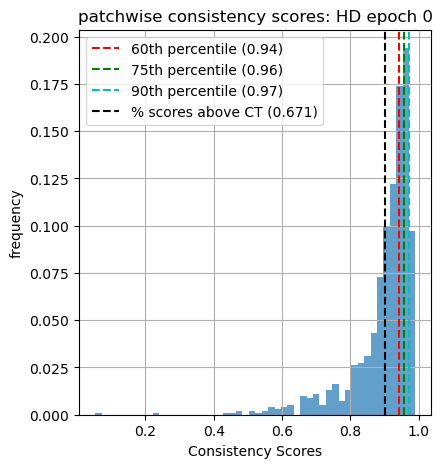

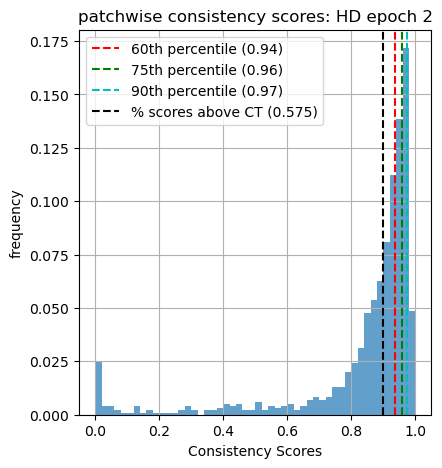

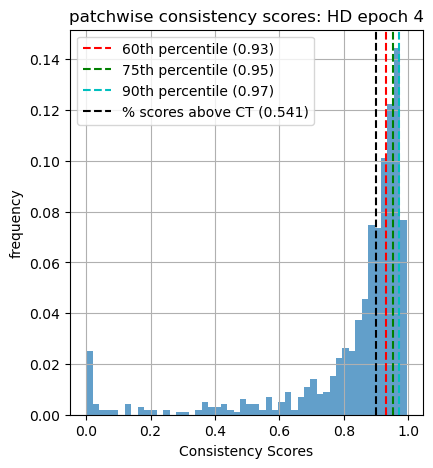

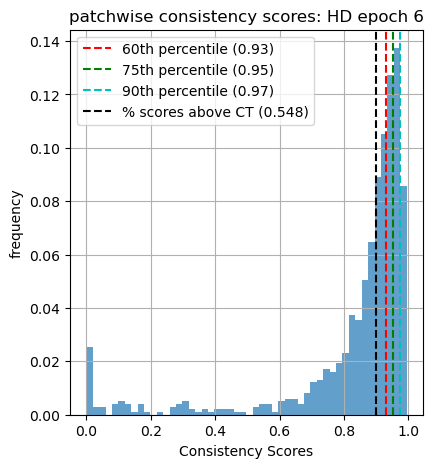

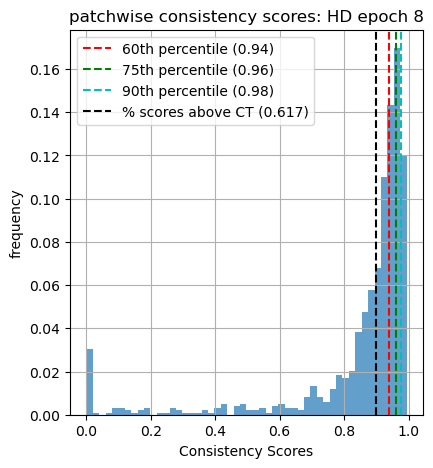

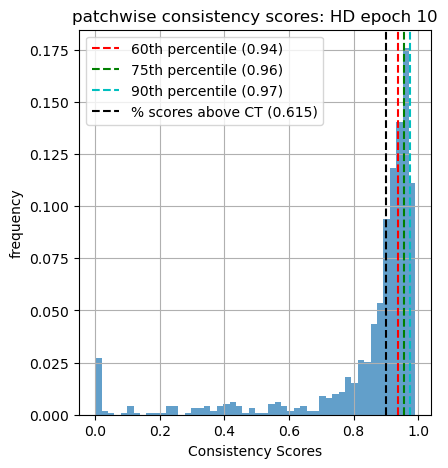

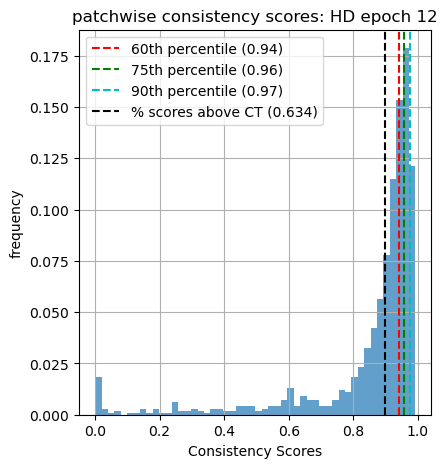

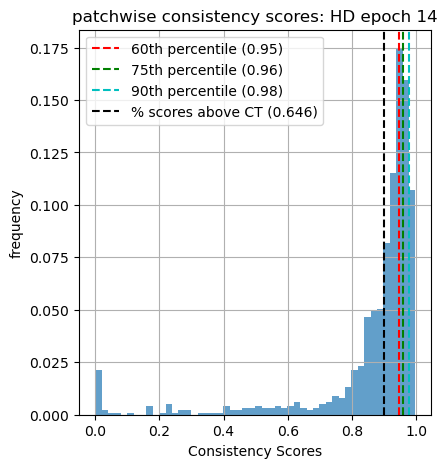

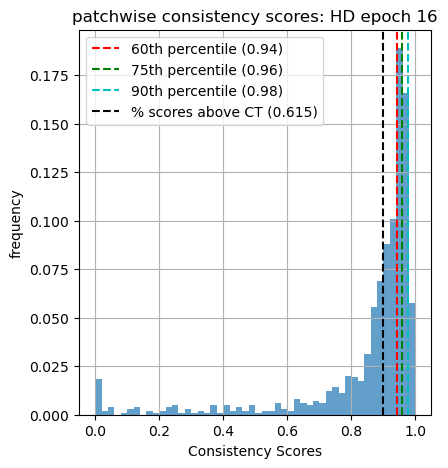

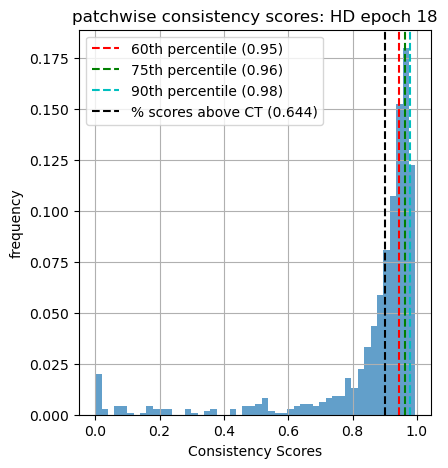

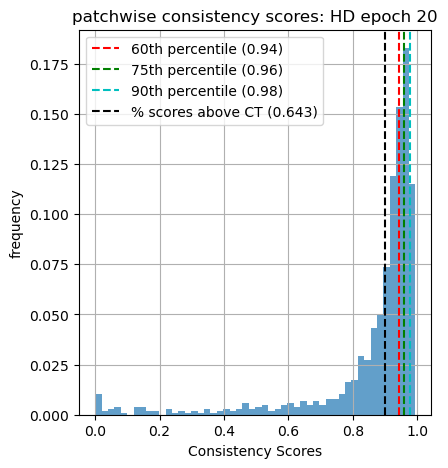

In [8]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_HD"
data_paths = Path(base_dir_path).glob("*.npz")
data_paths = sorted(data_paths, key=alphanum_key)

for i, data_path in enumerate(data_paths):
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = 1 - np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9, title_postfix=f"HD epoch {2*i}")

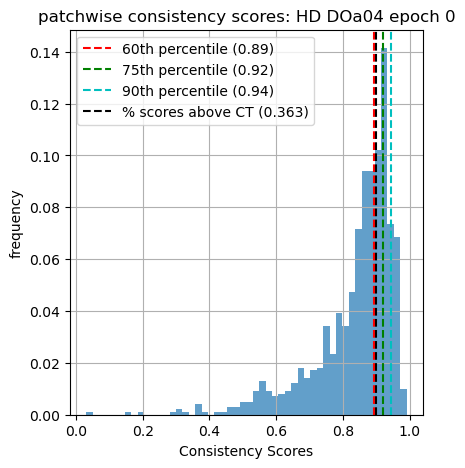

In [9]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/HD_DOa04"
data_paths = Path(base_dir_path).glob("*.npz")
data_paths = sorted(data_paths, key=alphanum_key)

for i, data_path in enumerate(data_paths):
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = 1 - np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9, title_postfix=f"HD DOa04 epoch {2*i}")